# NexaPay — Python Business Analysis

### Objective
Analyze customer behavior, transaction performance, fraud risk, merchant performance,
chargebacks, and customer support to identify actionable business insights.

### Analytical Areas
- Customer Behavior
- Transaction Performance
- Payment Methods
- Merchant Performance
- Fraud & Risk
- Chargebacks
- Customer Support

*Importing Libraries*

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

*Loading the Analytical Tables For Python ANALYSIS*

In [3]:
customer_analysis = pd.read_csv(
    "analytical_data/customer_analysis.csv"
)

account_analysis = pd.read_csv(
    "analytical_data/account_analysis.csv"
)

merchant_analysis = pd.read_csv(
    "analytical_data/merchant_analysis.csv"
)

chargeback_analysis = pd.read_csv(
    "analytical_data/chargeback_analysis.csv"
)

support_analysis = pd.read_csv(
    "analytical_data/support_analysis.csv"
)

In [4]:

transaction_analysis = pd.read_csv(
    "analytical_data/transaction_analysis.csv"
)

In [5]:
customer_analysis.head()

,customer_id,customer_tenure_months,age,city,state,customer_segment,income_band,kyc_status,acquisition_channel,signup_date,risk_band,total_transactions,total_transaction_value,average_transaction_value,successful_transactions,failed_transactions,fraud_transactions,transaction_success_rate,transaction_failure_rate,fraud_rate
0,1,11,40,Chennai,Tamil Nadu,Mass,50K-100K,Verified,Digital,2025-01-31,Medium,32.0,137793.89,4306.059063,21.0,6.0,0.0,65.625000,18.750000,0.0
1,2,0,54,Pune,Maharashtra,Affluent,250K+,Verified,Digital,2025-12-30,Low,7.0,17695.15,2527.878571,5.0,2.0,0.0,71.428571,28.571429,0.0
2,3,20,72,Hyderabad,Telangana,Affluent,100K-250K,Verified,Digital,2024-05-10,Medium,29.0,80422.99,2773.206552,21.0,2.0,0.0,72.413793,6.896552,0.0
3,4,5,68,Mumbai,Maharashtra,Mass,25K-50K,Verified,Branch,2025-07-18,Medium,25.0,278110.33,11124.413200,21.0,2.0,0.0,84.000000,8.000000,0.0
4,5,11,65,Ahmedabad,Gujarat,Mass,25K-50K,Verified,Digital,2025-02-04,Low,12.0,57457.95,4788.162500,9.0,2.0,0.0,75.000000,16.666667,0.0


In [6]:
kpis = {
    "Customers": len(customer_analysis),
    "Transactions": len(transaction_analysis),
    "Merchants": len(merchant_analysis),
    "Chargebacks": len(chargeback_analysis),
    "Support Tickets": len(support_analysis)
}

pd.Series(kpis)

Customers           120000
Transactions       1500000
Merchants            35000
Chargebacks          24000
Support Tickets      90000
dtype: int64

*How is customer transaction activity distributed across NexaPay's customer base*

In [5]:
customer_analysis[["customer_id","total_transactions"]].head()

,customer_id,total_transactions
0,1,32.0
1,2,7.0
2,3,29.0
3,4,25.0
4,5,12.0


In [6]:
customer_analysis['total_transactions'].describe()

count    120000.000000
mean         12.500000
std          10.807639
min           0.000000
25%           4.000000
50%          11.000000
75%          19.000000
max          87.000000
Name: total_transactions, dtype: float64

In [8]:
customer_analysis["engagement_level"] = pd.cut(
    customer_analysis["total_transactions"],
    bins=[-1, 5, 20, 50, np.inf],
    labels=[
        "Low Engagement",
        "Moderate Engagement",
        "High Engagement",
        "Very High Engagement"
    ]
)

In [9]:
engagement_counts = (
    customer_analysis["engagement_level"]
    .value_counts()
    .sort_index()
)

engagement_counts

engagement_level
Low Engagement          33386
Moderate Engagement     61222
High Engagement         24915
Very High Engagement      477
Name: count, dtype: int64

C:\Users\USER\AppData\Local\Temp\ipykernel_6996\2055817130.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


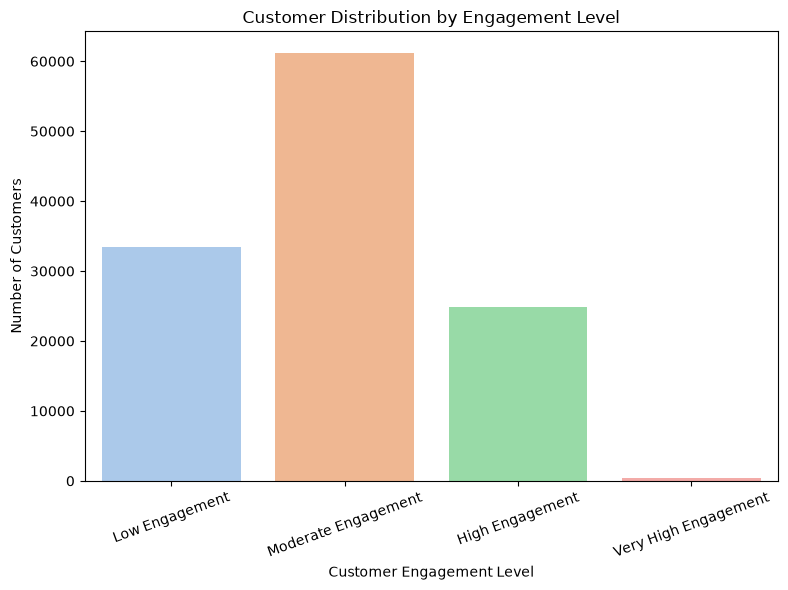

In [15]:
plt.figure(figsize=(8, 6))

sns.countplot(
    data=customer_analysis,
    x="engagement_level",
    order=[
        "Low Engagement",
        "Moderate Engagement",
        "High Engagement",
        "Very High Engagement"
    ],palette='pastel'
)

plt.title("Customer Distribution by Engagement Level")
plt.xlabel("Customer Engagement Level")
plt.ylabel("Number of Customers")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Insight: 
Most of the Customers belong to Moderate Engagement Category indicating that customers have a decent activity on Platform

*Which customer segments have the highest transaction frequency?*

In [17]:
customer_analysis.head(2)

,customer_id,customer_tenure_months,age,city,state,customer_segment,income_band,kyc_status,acquisition_channel,signup_date,...,total_transactions,total_transaction_value,average_transaction_value,successful_transactions,failed_transactions,fraud_transactions,transaction_success_rate,transaction_failure_rate,fraud_rate,engagement_level
0,1,11,40,Chennai,Tamil Nadu,Mass,50K-100K,Verified,Digital,2025-01-31,...,32.0,137793.89,4306.059063,21.0,6.0,0.0,65.625000,18.750000,0.0,High Engagement
1,2,0,54,Pune,Maharashtra,Affluent,250K+,Verified,Digital,2025-12-30,...,7.0,17695.15,2527.878571,5.0,2.0,0.0,71.428571,28.571429,0.0,Moderate Engagement


In [33]:
segment_frequency = (
    customer_analysis
    .groupby("customer_segment")["total_transactions"]
    .mean()
    .sort_values(ascending=False)
)

segment_frequency

customer_segment
SME         12.627985
Mass        12.548462
Affluent    12.438914
Premium     12.404360
Name: total_transactions, dtype: float64

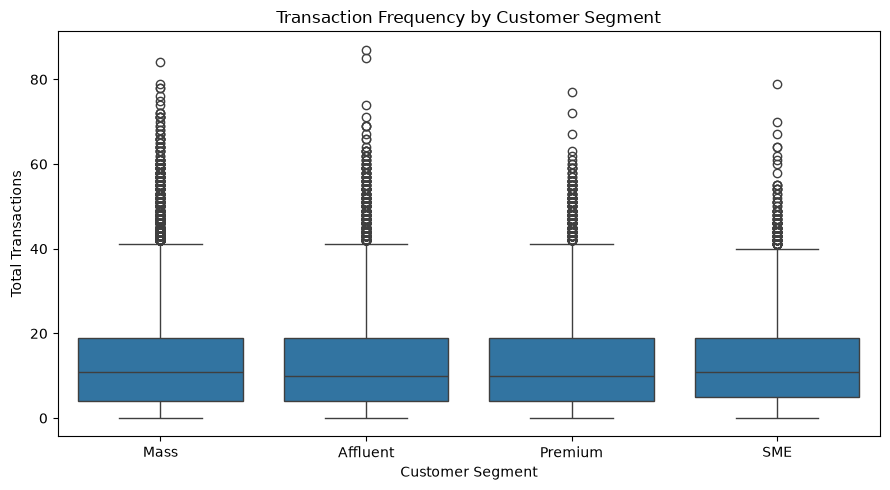

In [34]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=customer_analysis,
    x="customer_segment",
    y="total_transactions"
)

plt.title("Transaction Frequency by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Transactions")


plt.tight_layout()
plt.show()

Insight:
        MASS & SME segments show slighter higher Median transaction activity while other have MORE Outliers 

*Which acquisition channels generates the Highest Total Transaction Value?*

In [35]:
channel_value = (
    customer_analysis
    .groupby("acquisition_channel")["total_transaction_value"]
    .sum()
)

channel_value

acquisition_channel
Branch      9.516740e+08
Digital     2.459611e+09
Partner     8.489055e+08
Referral    4.818554e+08
Name: total_transaction_value, dtype: float64

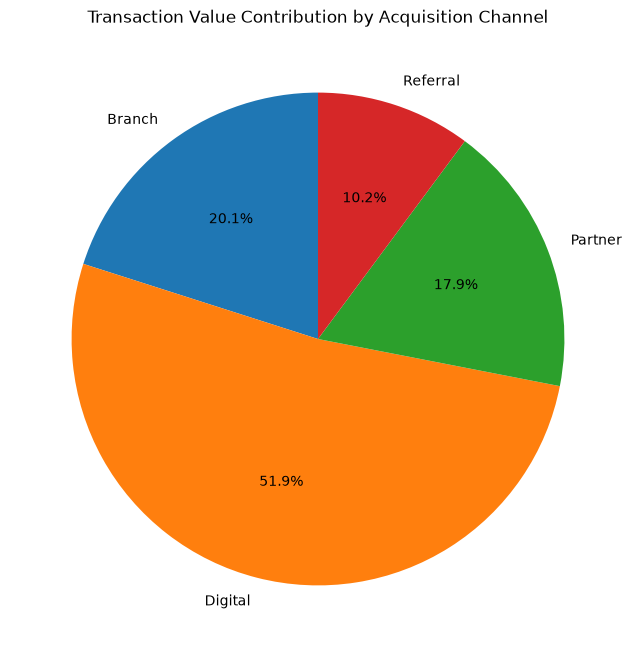

In [39]:
plt.figure(figsize=(8, 8))

plt.pie(
    channel_value,
    labels=channel_value.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Transaction Value Contribution by Acquisition Channel")

plt.show()

Insight: DIGITAL has largest share in NEXAPAY'S Total Transaction Value

Does customer tenure influence transaction activity?

In [37]:
tenure_activity = (
    customer_analysis
    .groupby("customer_tenure_months")["total_transactions"]
    .mean()
)

tenure_activity.head()

customer_tenure_months
0    12.364322
1    13.002454
2    12.502864
3    12.575795
4    12.533933
Name: total_transactions, dtype: float64

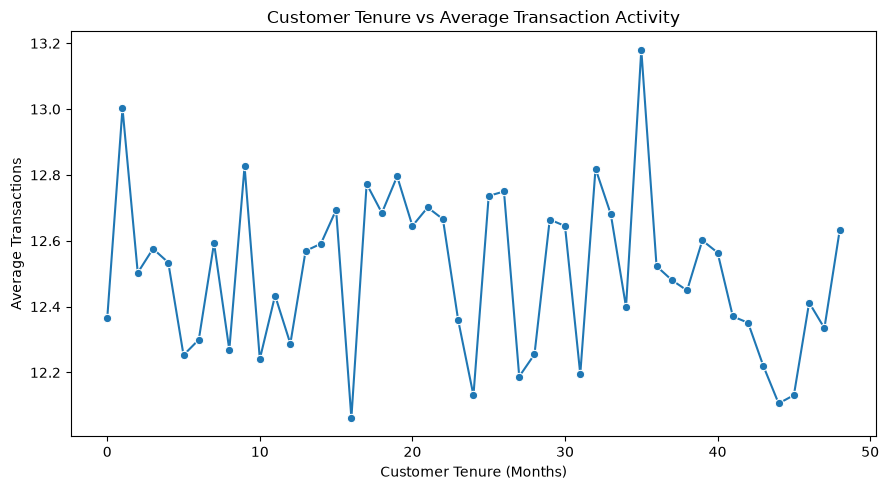

In [43]:
plt.figure(figsize=(9, 5))

sns.lineplot(
    x=tenure_activity.index,
    y=tenure_activity.values,
    marker="o"
)

plt.title("Customer Tenure vs Average Transaction Activity")
plt.xlabel("Customer Tenure (Months)")
plt.ylabel("Average Transactions")

plt.tight_layout()
plt.show()

Which Channels bring the most valueable customers to NexaPay

In [44]:
channel_value = (
    customer_analysis
    .groupby("acquisition_channel")["total_transaction_value"]
    .sum()
    .sort_values(ascending=False)
)

channel_value

acquisition_channel
Digital     2.459611e+09
Branch      9.516740e+08
Partner     8.489055e+08
Referral    4.818554e+08
Name: total_transaction_value, dtype: float64

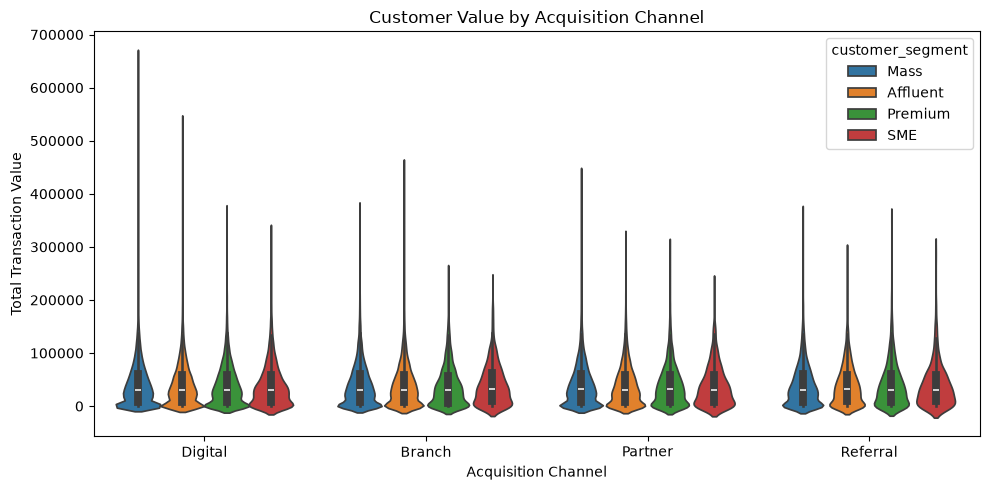

In [46]:
plt.figure(figsize=(10, 5))

sns.violinplot(
    data=customer_analysis,
    x="acquisition_channel",
    y="total_transaction_value",
    hue="customer_segment",
    split=False
)

plt.title("Customer Value by Acquisition Channel")
plt.xlabel("Acquisition Channel")
plt.ylabel("Total Transaction Value")


plt.tight_layout()
plt.show()

Insight: Digital and Branch channels show the highest customer transaction values, with Premium and SME customers contributing strongly across channels.

Does The Cutomers Risk level Affect Transaction Activity

In [47]:
risk_activity = (
    customer_analysis
    .groupby("risk_band")["total_transactions"]
    .mean()
)

risk_activity

risk_band
High      12.667960
Low       12.527325
Medium    12.406563
Name: total_transactions, dtype: float64

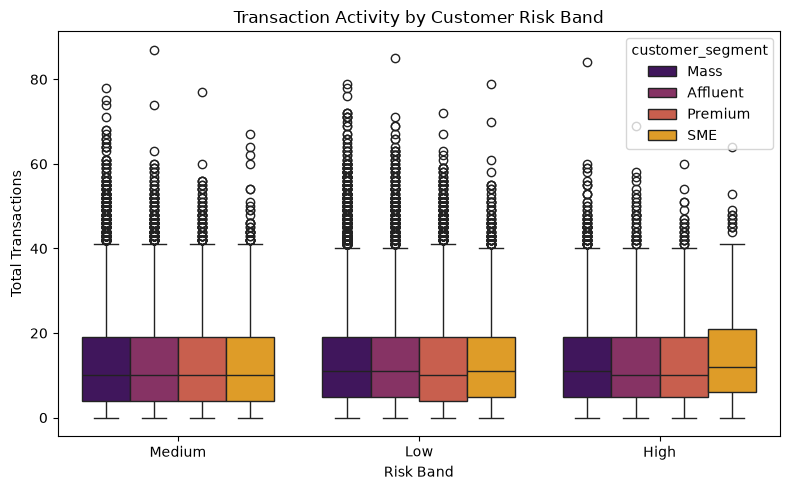

In [49]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=customer_analysis,
    x="risk_band",
    y="total_transactions",
    hue="customer_segment",palette='inferno'
)

plt.title("Transaction Activity by Customer Risk Band")
plt.xlabel("Risk Band")
plt.ylabel("Total Transactions")

plt.tight_layout()
plt.show()

Insight: Transaction activity is broadly similar across risk bands, but high-risk SME customers show slightly higher median activity.


Customer Segement with higher transaction failure rate

In [50]:
failure_rate = (
    customer_analysis
    .groupby("customer_segment")["transaction_failure_rate"]
    .mean()
    .sort_values(ascending=False)
)

failure_rate

customer_segment
SME         7.635011
Mass        7.498541
Affluent    7.485148
Premium     7.429009
Name: transaction_failure_rate, dtype: float64

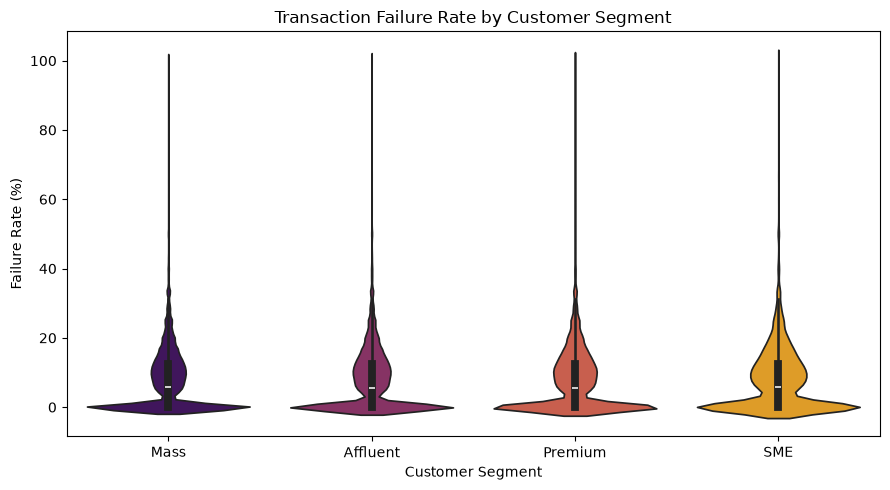

In [52]:
plt.figure(figsize=(9, 5))

sns.violinplot(
    data=customer_analysis,
    x="customer_segment",
    y="transaction_failure_rate",
    hue="customer_segment",
    legend=False,palette='inferno'
)

plt.title("Transaction Failure Rate by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Failure Rate (%)")

plt.tight_layout()
plt.show()

Insight: The SME segment shows the highest and widest failure rate distribution

Does Customer Tenure influence transaction value

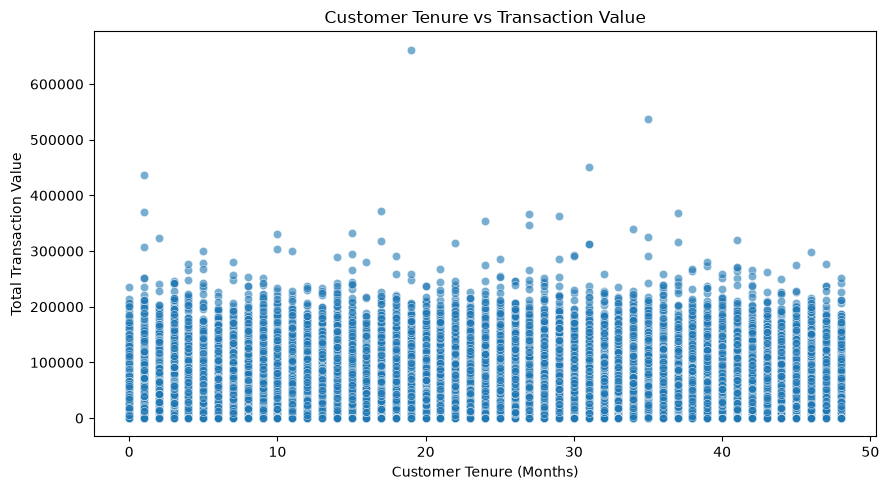

In [55]:
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=customer_analysis,
    x="customer_tenure_months",
    y="total_transaction_value",
    
    alpha=0.6
)

plt.title("Customer Tenure vs Transaction Value")
plt.xlabel("Customer Tenure (Months)")
plt.ylabel("Total Transaction Value")

plt.tight_layout()
plt.show()

Insight: The Relationship is Apperaing to be Weak 

Which Channels are the most successful for attracting customers across different Customer Segements 

In [56]:
channel_segment = pd.crosstab(
    customer_analysis["acquisition_channel"],
    customer_analysis["customer_segment"]
)

channel_segment

customer_segment,Affluent,Mass,Premium,SME
acquisition_channel,,,,
Branch,6724,12613,3634,1172
Digital,17523,32250,9501,3061
Partner,6086,11181,3104,1048
Referral,3357,6294,1787,665


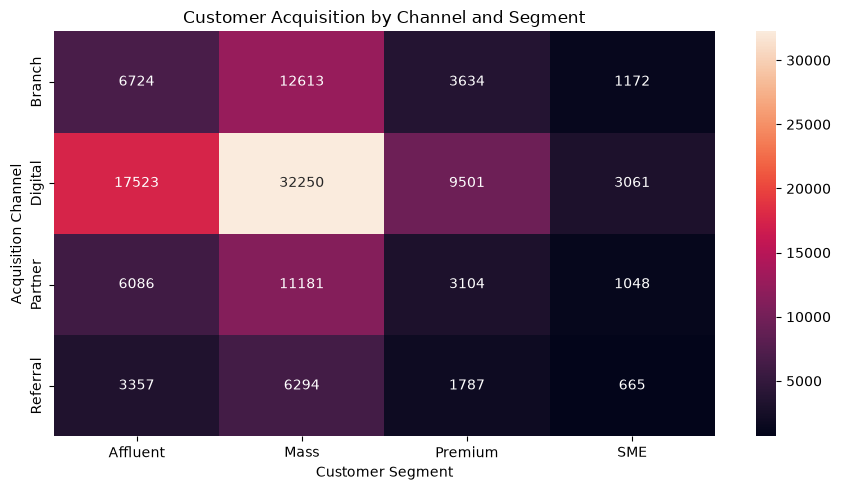

In [57]:
plt.figure(figsize=(9, 5))

sns.heatmap(
    channel_segment,
    annot=True,
    fmt="d"
)

plt.title("Customer Acquisition by Channel and Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Acquisition Channel")

plt.tight_layout()
plt.show()

Insights: It helps to Identify which Channels are the Strongest for each Customer Group

Transaction Activity Change Over Time

In [62]:
monthly_transactions = (
    transaction_analysis
    .groupby("transaction_month")["transaction_id"]
    .count()
)

monthly_transactions.head(5)

transaction_month
2022-03      6
2022-04     28
2022-05     44
2022-06    105
2022-07    198
Name: transaction_id, dtype: int64

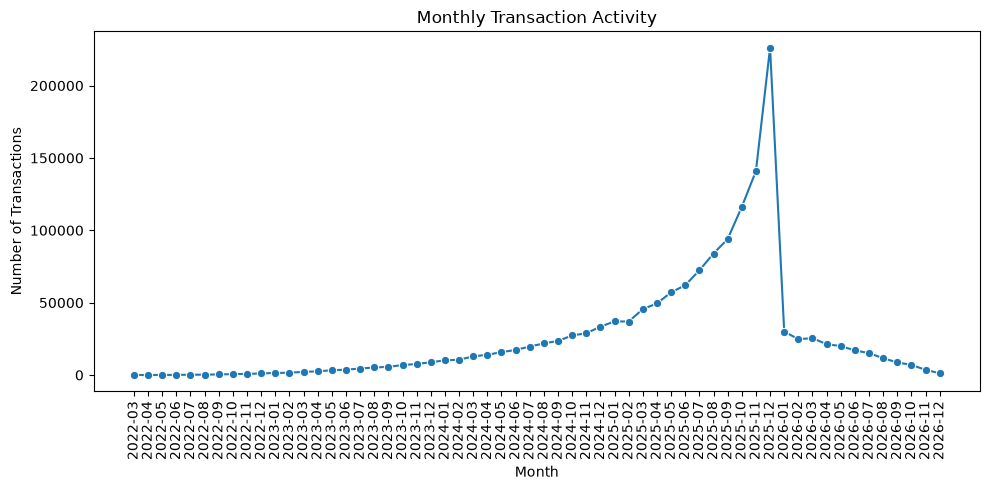

In [64]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    x=monthly_transactions.index,
    y=monthly_transactions.values,
    marker="o"
)

plt.title("Monthly Transaction Activity")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Insight: Transaction activity increased sharply through 2025, peaked in December 2025, and then declined significantly in 2026.

Transaction Status Graph across Months 

In [65]:
monthly_status = (
    transaction_analysis
    .groupby(["transaction_month", "transaction_status"])
    .size()
    .reset_index(name="transactions")
)

monthly_status.head()

,transaction_month,transaction_status,transactions
0,2022-03,Failed,1
1,2022-03,Success,5
2,2022-04,Failed,3
3,2022-04,Pending,2
4,2022-04,Success,23


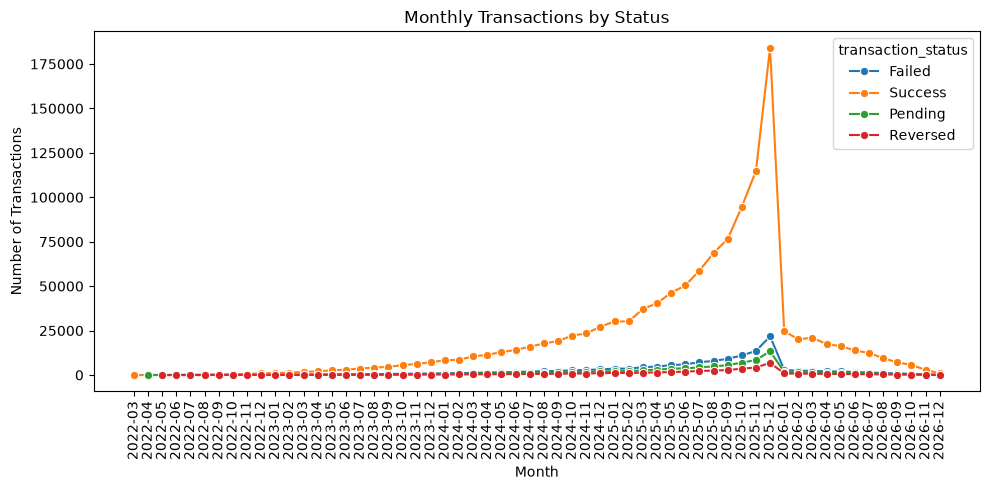

In [67]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=monthly_status,
    x="transaction_month",
    y="transactions",
    hue="transaction_status",
    marker="o"
)

plt.title("Monthly Transactions by Status")
plt.xlabel("Month")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Insight: Successful transactions dominate throughout the period, with a sharp peak in December 2025. Failed and pending transactions also increased during this peak.

Which Day of the week has the Higher Transaction activity

In [68]:
day_activity = (
    transaction_analysis
    .groupby("day_of_week")["transaction_id"]
    .count()
    .reindex([
        "Monday", "Tuesday", "Wednesday",
        "Thursday", "Friday", "Saturday", "Sunday"
    ])
)

day_activity

day_of_week
Monday       214274
Tuesday      217556
Wednesday    220873
Thursday     209577
Friday       211008
Saturday     212505
Sunday       214207
Name: transaction_id, dtype: int64

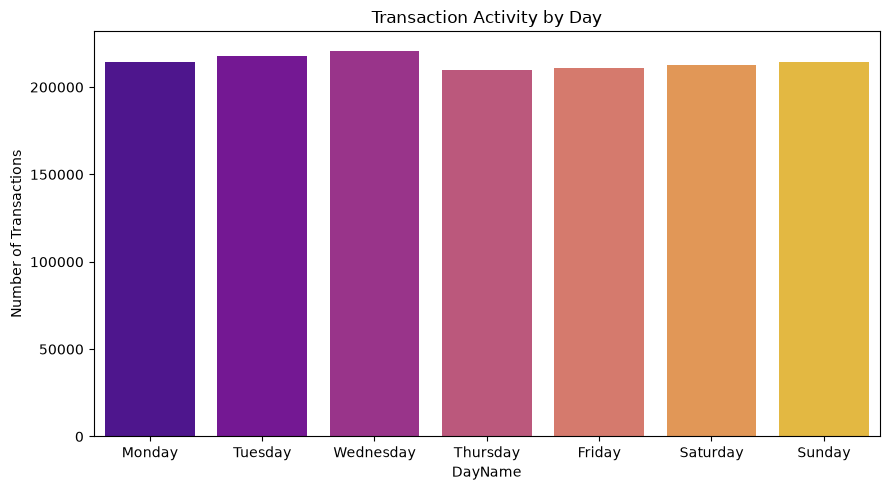

In [71]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=day_activity.index,
    y=day_activity.values,
    hue=day_activity.index,
    legend=False,palette='plasma'
)

plt.title("Transaction Activity by Day")
plt.xlabel("DayName")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

Insights: WEDNESDAY is the Day hich has the Highest Transactions Volume 

Transaction Activity Differ Between WeekDays V/S WeekEnds

In [72]:
weekend_activity = (
    transaction_analysis
    .groupby("is_weekend")["transaction_id"]
    .count()
)

weekend_activity.index = ["Weekday", "Weekend"]

weekend_activity

Weekday    1073288
Weekend     426712
Name: transaction_id, dtype: int64

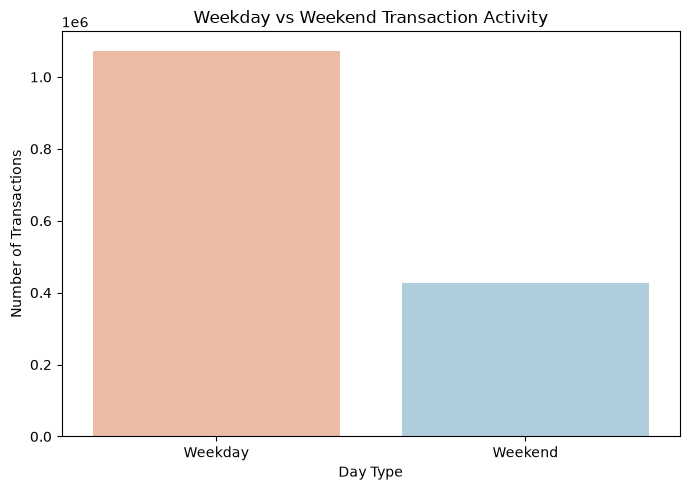

In [77]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=weekend_activity.index,
    y=weekend_activity.values,
    hue=weekend_activity.index,
    legend=False,palette='RdBu'
)

plt.title("Weekday vs Weekend Transaction Activity")
plt.xlabel("Day Type")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

Insights: Transactions Activity are Higher on WEEKDAYS

Which Payments Methods are used more And How they Differ From the Transaction Status 

In [78]:
payment_status = pd.crosstab(
    transaction_analysis["payment_method"],
    transaction_analysis["transaction_status"]
)

payment_status

transaction_status,Failed,Pending,Reversed,Success
payment_method,,,,
Bank Transfer,17539,10553,5235,146081
Card,39161,24099,12310,330012
Net Banking,24809,15133,7671,207396
UPI,52032,32394,16122,439548
Wallet,11380,7100,3555,97870


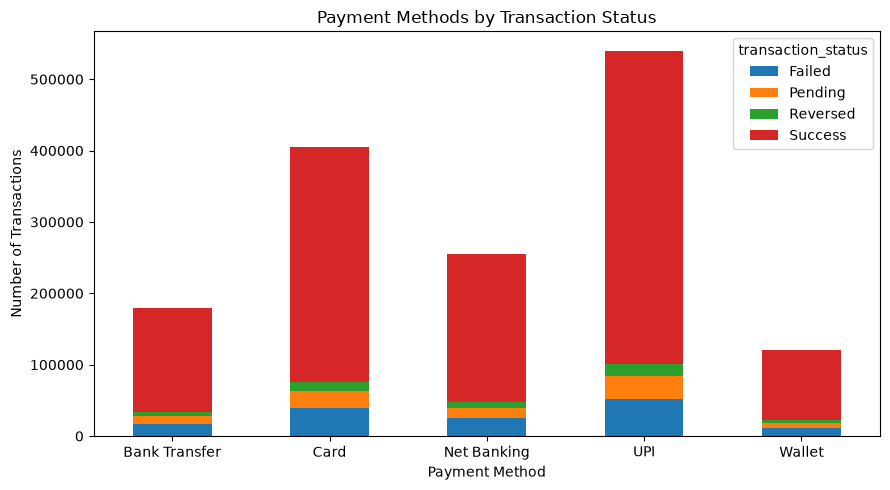

In [89]:
payment_status.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5)
)

plt.title("Payment Methods by Transaction Status")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Insights: UPI Dominates the Total Transactions by any PaymentMethod but also has Most Failed Transactions  

*Which merchant categories generate the highest transaction value?*

In [6]:
merchant_category_value = (
    transaction_analysis
    .merge(
        merchant_analysis[["merchant_id", "merchant_category"]],
        on="merchant_id",
        how="left"
    )
    .groupby("merchant_category")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

merchant_category_value

merchant_category
E-commerce       4.931186e+08
Utilities        4.892967e+08
Healthcare       4.784133e+08
Travel           4.761283e+08
Fashion          4.738401e+08
Electronics      4.734028e+08
Grocery          4.717697e+08
Dining           4.666254e+08
Entertainment    4.599073e+08
Education        4.595434e+08
Name: amount_inr, dtype: float64

C:\Users\USER\AppData\Local\Temp\ipykernel_4912\508335357.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


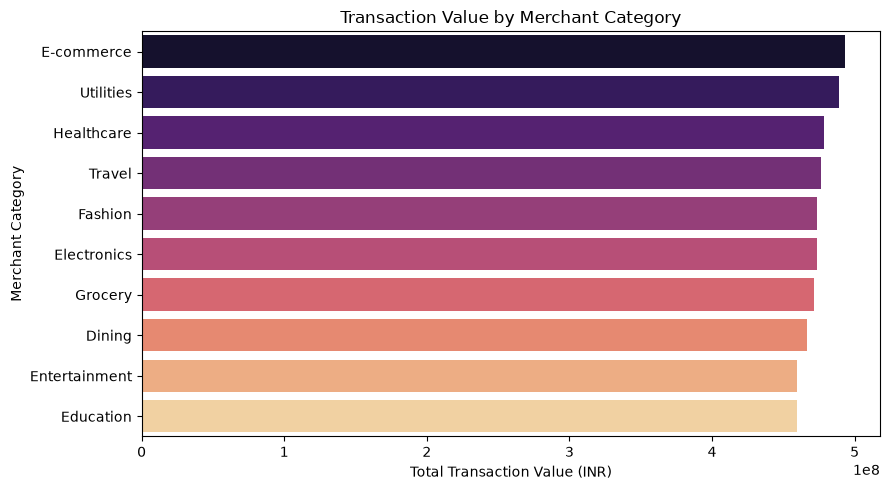

In [8]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=merchant_category_value.values,
    y=merchant_category_value.index,palette='magma'
)

plt.title("Transaction Value by Merchant Category")
plt.xlabel("Total Transaction Value (INR)")
plt.ylabel("Merchant Category")

plt.tight_layout()
plt.show()

Insight: E-Commerce generates the highest transaction value,making it Important merchant category for Nexapay

Merchant Having High Transaction Volume but Poor Success Rate

In [11]:
merchant_analysis[
    [
        "merchant_id",
        "merchant_name",
        "total_transactions",
        "success_rate"
    ]
].sort_values(
    "total_transactions",
    ascending=False
).head(10)

,merchant_id,merchant_name,total_transactions,success_rate
22379,22379,Merchant_22379,73,76.712329
10828,10828,Merchant_10828,73,86.301370
10222,10222,Merchant_10222,70,80.000000
15951,15951,Merchant_15951,70,81.428571
11659,11659,Merchant_11659,70,80.000000
15022,15022,Merchant_15022,68,82.352941
28479,28480,Merchant_28480,68,79.411765
28810,28811,Merchant_28811,67,82.089552
34081,34082,Merchant_34082,67,80.597015
28223,28224,Merchant_28224,67,85.074627


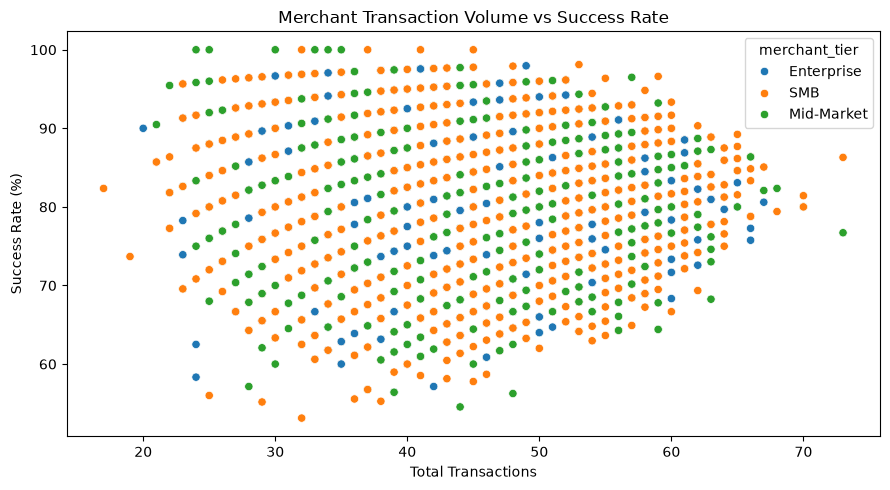

In [14]:
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=merchant_analysis,
    x="total_transactions",
    y="success_rate",hue='merchant_tier'
)

plt.title("Merchant Transaction Volume vs Success Rate")
plt.xlabel("Total Transactions")
plt.ylabel("Success Rate (%)")

plt.tight_layout()
plt.show()

*Is Merchant Risk Rating related with transaction failure Rates*

In [15]:
risk_failure = (
    transaction_analysis
    .merge(
        merchant_analysis[["merchant_id", "risk_rating"]],
        on="merchant_id",
        how="left"
    )
    .groupby("risk_rating")["is_failed"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

risk_failure

risk_rating
High      11.136085
Medium     9.597113
Low        9.526694
Name: is_failed, dtype: float64

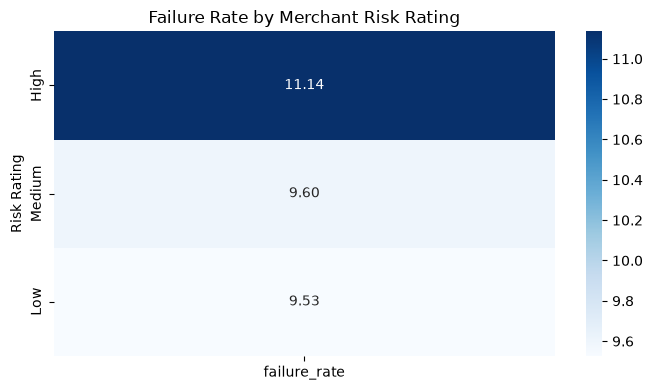

In [16]:
heatmap_data = risk_failure.to_frame("failure_rate")

plt.figure(figsize=(7, 4))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title("Failure Rate by Merchant Risk Rating")
plt.xlabel("")
plt.ylabel("Risk Rating")

plt.tight_layout()
plt.show()

Transaction activity Distributed across Different Hours of Day

In [17]:
hourly_activity = (
    transaction_analysis
    .groupby("transaction_hour")["transaction_id"]
    .count()
)

hourly_activity

transaction_hour
0     62961
1     61982
2     62409
3     62364
4     62935
5     62183
6     62643
7     62501
8     62597
9     62497
10    62092
11    62543
12    62625
13    62291
14    62612
15    62647
16    62438
17    62549
18    62270
19    62686
20    62687
21    62728
22    62315
23    62445
Name: transaction_id, dtype: int64

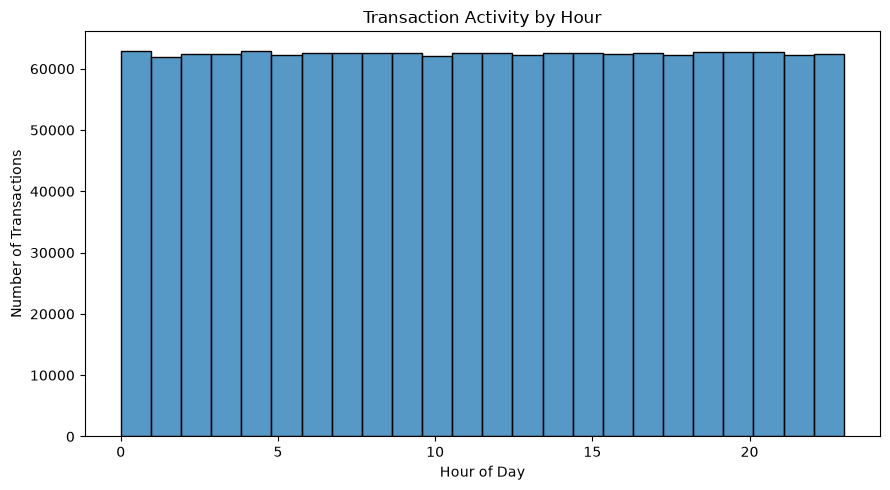

In [18]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=transaction_analysis,
    x="transaction_hour",
    bins=24
)

plt.title("Transaction Activity by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

Transaction Failure Rate Distribution across Different Hours of the DAY

In [19]:
hourly_failure = (
    transaction_analysis
    .groupby("transaction_hour")["is_failed"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

hourly_failure.head(10)

transaction_hour
17    9.801915
1     9.783486
8     9.780021
12    9.772455
11    9.769279
21    9.750032
9     9.733267
0     9.733009
14    9.731361
6     9.718564
Name: is_failed, dtype: float64

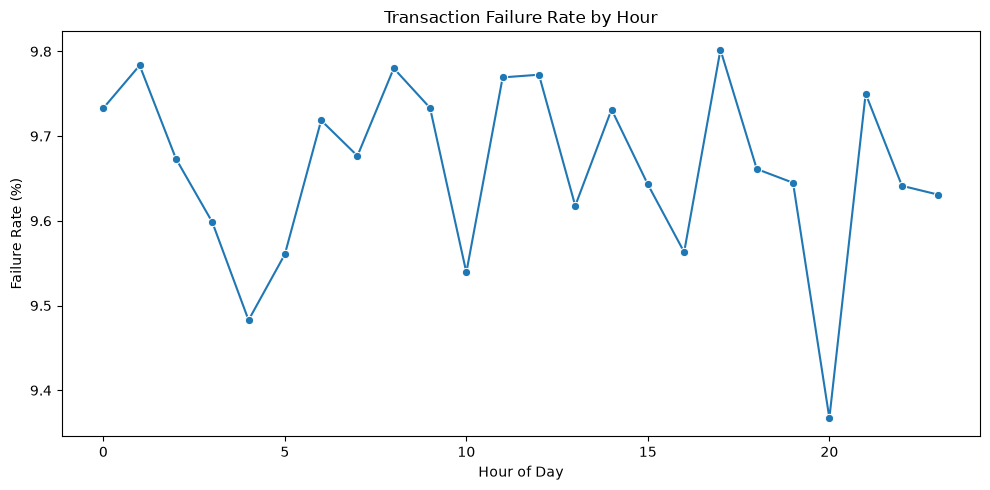

In [20]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    x=hourly_failure.index,
    y=hourly_failure.values,
    marker="o"
)

plt.title("Transaction Failure Rate by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Failure Rate (%)")

plt.tight_layout()
plt.show()

ChargeBack Reasons which Create the Highest Financial Exposure?

In [30]:
chargeback_reason = (
    chargeback_analysis
    .groupby("reason_code")["chargeback_amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

chargeback_reason

reason_code
Fraud                       18086778.31
Product Not Received         9652725.79
Product Not as Described     7907783.98
Processing Error             7273862.09
Duplicate                    4899281.25
Name: chargeback_amount_inr, dtype: float64

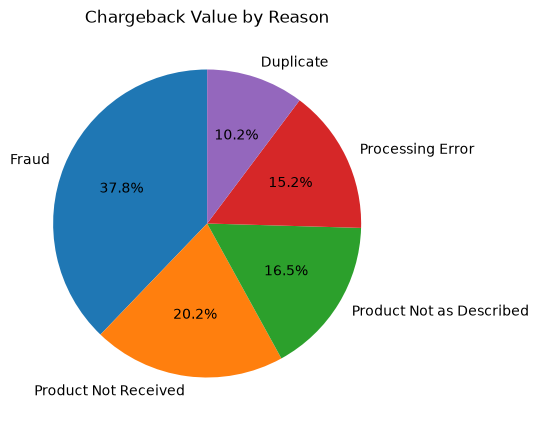

In [32]:
plt.figure(figsize=(8, 5))

plt.pie(
    chargeback_reason,
    labels=chargeback_reason.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Chargeback Value by Reason")

plt.show()

ChargeBack Amount V/S The ChargeBack Recovery

In [33]:
recovery = chargeback_analysis[
    ["chargeback_amount_inr", "recovery_amount_inr"]
].sum()

recovery

chargeback_amount_inr    47820431.42
recovery_amount_inr      20369255.70
dtype: float64

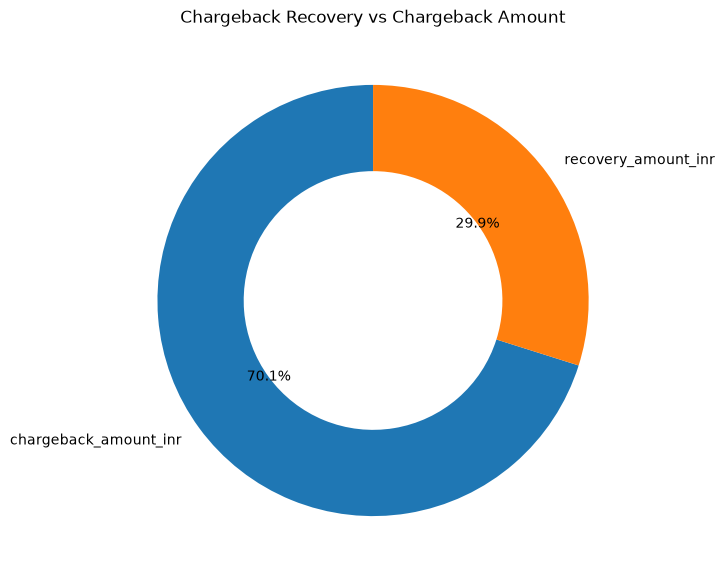

In [34]:
plt.figure(figsize=(7, 7))

plt.pie(
    recovery,
    labels=recovery.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.4}
)

plt.title("Chargeback Recovery vs Chargeback Amount")
plt.show()

Which Support Issue creates the highest Customer Service Workload?

In [38]:
issue_status = pd.crosstab(
    support_analysis["issue_category"],
    support_analysis["ticket_status"]
)

issue_status

ticket_status,Closed,In Progress,Open,Resolved
issue_category,,,,
Account Access,4826,1347,702,5843
Chargeback,2817,671,414,3366
Fraud Alert,3482,898,545,4165
General Inquiry,4080,1052,629,4947
KYC,3496,867,560,4097
Merchant Dispute,3503,892,526,4110
Payment Failure,8083,2207,1264,9876
Refund,4099,1076,682,4878


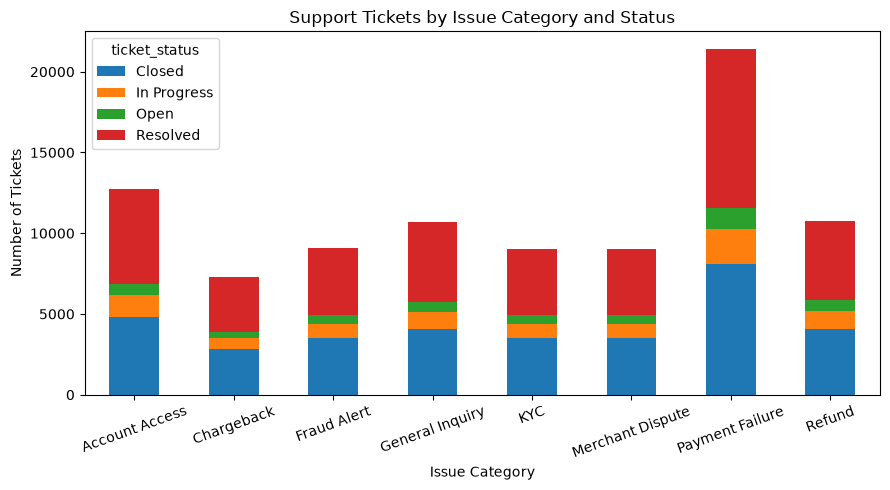

In [39]:
issue_status.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5)
)

plt.title("Support Tickets by Issue Category and Status")
plt.xlabel("Issue Category")
plt.ylabel("Number of Tickets")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Insight: Payment Failure generates the highest support workload, followed by Account Access. This suggests payment issues are the biggest customer-service 

Customer Segment with Higher Number of Support Tickets 

In [44]:
support_segment = (
    support_analysis
    .merge(
        customer_analysis[["customer_id", "customer_segment"]],
        on="customer_id",
        how="left"
    )
    .groupby("customer_segment")["ticket_id"]
    .count()
    .sort_values(ascending=False)
)

support_segment

customer_segment
Mass        46637
Affluent    25301
Premium     13651
SME          4411
Name: ticket_id, dtype: int64

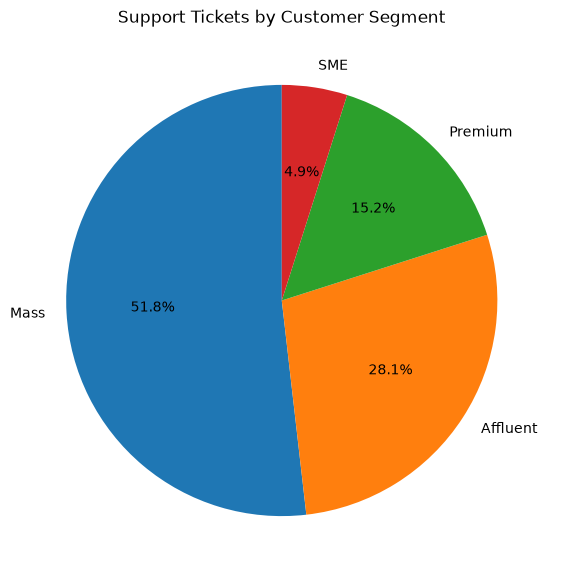

In [46]:
plt.figure(figsize=(7, 7))

plt.pie(
    support_segment,
    labels=support_segment.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Support Tickets by Customer Segment")
plt.show()

Insights: MASS Customer Segment has generated the More Number of Support Tickets 

Which Payment Method create the Highest Combined failure and Fraud Risk

In [52]:
payment_risk = (
    transaction_analysis
    .groupby("payment_method")
    .agg(
        failure_rate=("is_failed", "mean"),
        fraud_rate=("fraud_flag", "mean")
    )
)

payment_risk *= 100

payment_risk

,failure_rate,fraud_rate
payment_method,,
Bank Transfer,9.776041,1.158811
Card,9.655507,1.168937
Net Banking,9.728676,1.159175
UPI,9.633843,1.188863
Wallet,9.490847,1.177599


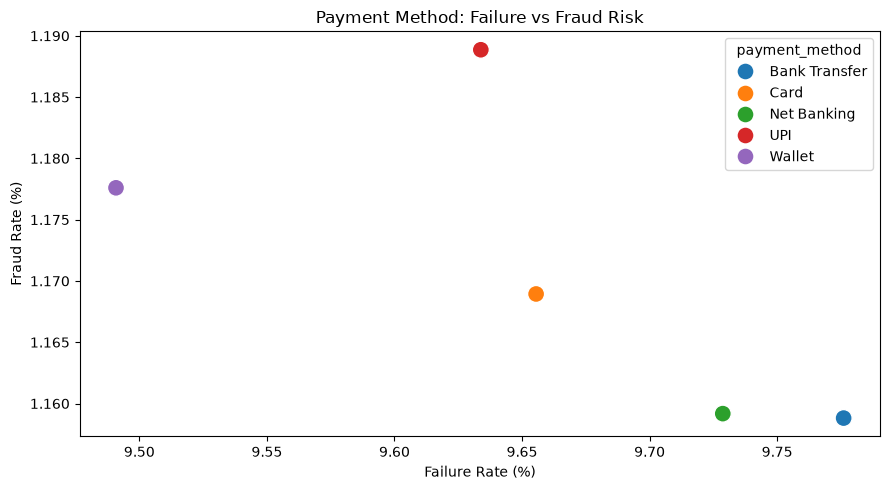

In [53]:
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=payment_risk,
    x="failure_rate",
    y="fraud_rate",
    hue=payment_risk.index,
    s=150
)

plt.title("Payment Method: Failure vs Fraud Risk")
plt.xlabel("Failure Rate (%)")
plt.ylabel("Fraud Rate (%)")

plt.tight_layout()
plt.show()

Insight: UPI has the highest fraud rate, while Bank Transfer has the highest failure rate. 

Does the TransactionFailure Varies by The CustomerSegment & PaymentMethod

In [58]:
segment_payment = (
    transaction_analysis
    .merge(
        customer_analysis[["customer_id", "customer_segment"]],
        on="customer_id",
        how="left"
    )
    .groupby(
        ["customer_segment", "payment_method"]
    )["is_failed"]
    .mean()
    .mul(100)
    .reset_index(name="failure_rate")
)

segment_payment

,customer_segment,payment_method,failure_rate
0,Affluent,Bank Transfer,9.655818
1,Affluent,Card,9.672855
2,Affluent,Net Banking,9.778083
3,Affluent,UPI,9.707882
4,Affluent,Wallet,9.437333
5,Mass,Bank Transfer,9.904038
6,Mass,Card,9.600968
7,Mass,Net Banking,9.718549
8,Mass,UPI,9.585572
9,Mass,Wallet,9.541100


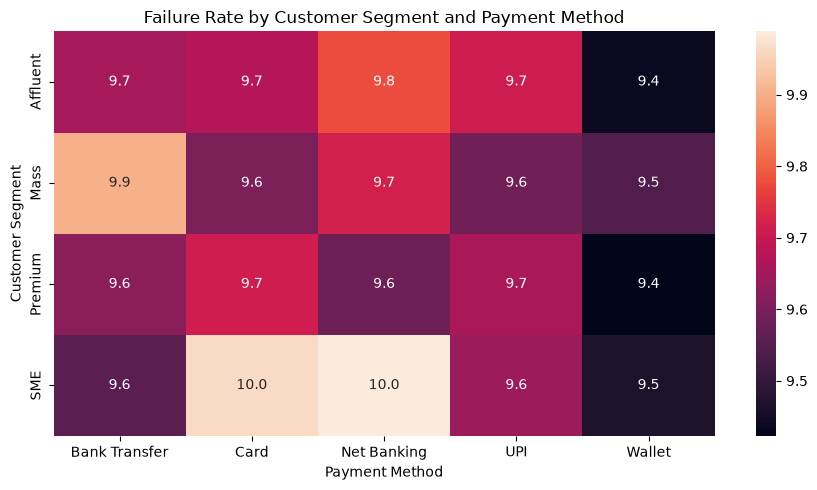

In [59]:
heatmap_data = segment_payment.pivot(
    index="customer_segment",
    columns="payment_method",
    values="failure_rate"
)

plt.figure(figsize=(9, 5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f"
)

plt.title("Failure Rate by Customer Segment and Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Customer Segment")

plt.tight_layout()
plt.show()

Insights: SME customers show the Highest Failure Rate with CARD & NET-Banking 

Which Acquisition Channel Brings The High Value Customers

In [60]:
channel_value = (
    customer_analysis
    .groupby("acquisition_channel")["total_transaction_value"]
    .mean()
    .sort_values(ascending=False)
)

channel_value

acquisition_channel
Referral    39812.886477
Partner     39633.292473
Digital     39457.941758
Branch      39418.217591
Name: total_transaction_value, dtype: float64

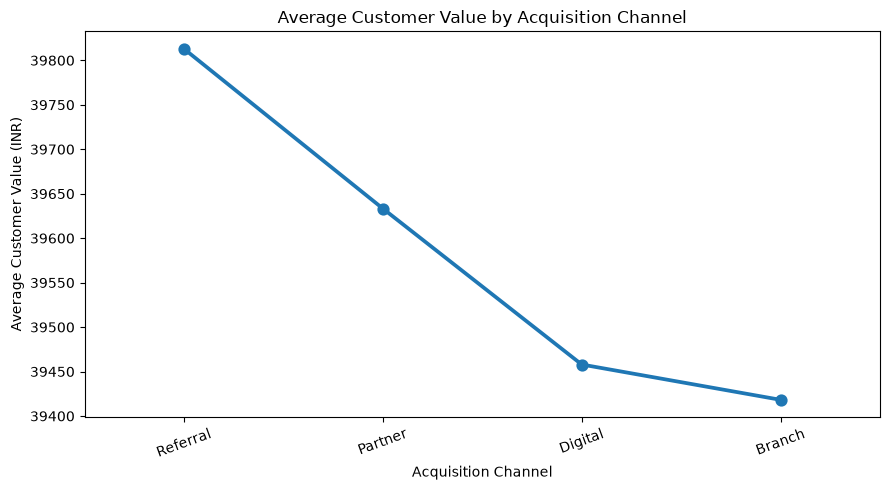

In [61]:
plt.figure(figsize=(9, 5))

sns.pointplot(
    x=channel_value.index,
    y=channel_value.values
)

plt.title("Average Customer Value by Acquisition Channel")
plt.xlabel("Acquisition Channel")
plt.ylabel("Average Customer Value (INR)")

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Insights: Referral brings out The HIGH VALUE CUSTOMERS [Customers who Generate More Transaction Value ]

KYC Status Variation across Customer Segments 

In [62]:
kyc_segment = pd.crosstab(
    customer_analysis["customer_segment"],
    customer_analysis["kyc_status"]
)

kyc_segment

kyc_status,Pending,Rejected,Verified
customer_segment,,,
Affluent,2371,692,30627
Mass,4427,1233,56678
Premium,1253,362,16411
SME,406,123,5417


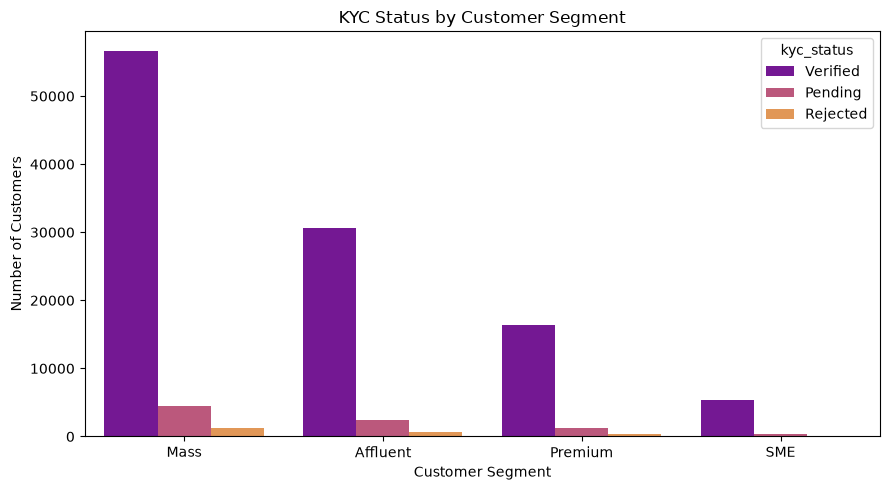

In [67]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=customer_analysis,
    x="customer_segment",
    hue="kyc_status",palette='plasma'
)

plt.title("KYC Status by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

Insights: MASS has the Highest Number Of KYC Verfied Customers , KYC Pending Customers & KYC Rejected Customers

*Which Payment Method carries the Highest Value of High Risk Transactions?*

In [14]:
high_risk = transaction_analysis[
    transaction_analysis["fraud_score"] >= 70
]

risk_summary = (
    high_risk
    .groupby("payment_method")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

risk_summary

payment_method
UPI              53300191.24
Card             41054835.08
Net Banking      25809422.87
Bank Transfer    17401521.17
Wallet           11877162.92
Name: amount_inr, dtype: float64

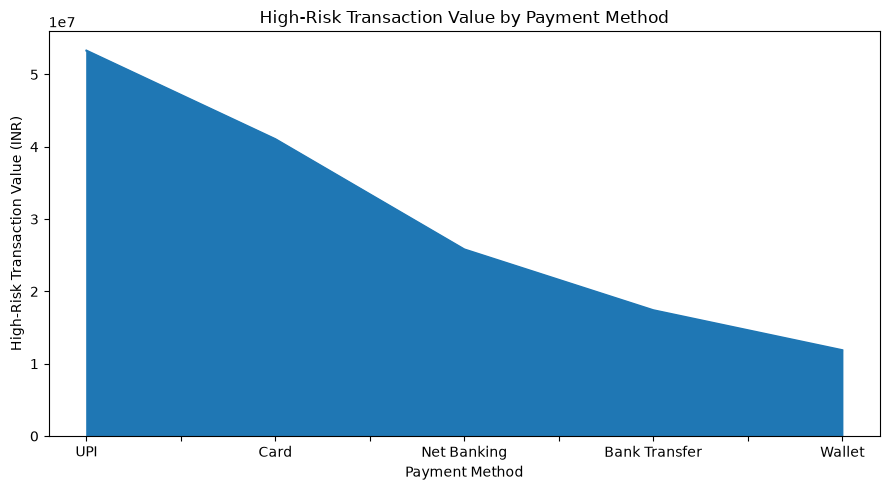

In [15]:
plt.figure(figsize=(9, 5))

risk_summary.plot(kind="area")

plt.title("High-Risk Transaction Value by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("High-Risk Transaction Value (INR)")

plt.tight_layout()
plt.show()

*Which acquisition channel has the highest customer tenure?*

In [20]:
channel_tenure = (
    customer_analysis
    .groupby("acquisition_channel")["customer_tenure_months"]
    .mean()
    .sort_values(ascending=False)
)

channel_tenure

acquisition_channel
Referral    24.002892
Digital     23.935397
Branch      23.839457
Partner     23.760726
Name: customer_tenure_months, dtype: float64

C:\Users\USER\AppData\Local\Temp\ipykernel_8844\3199405166.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


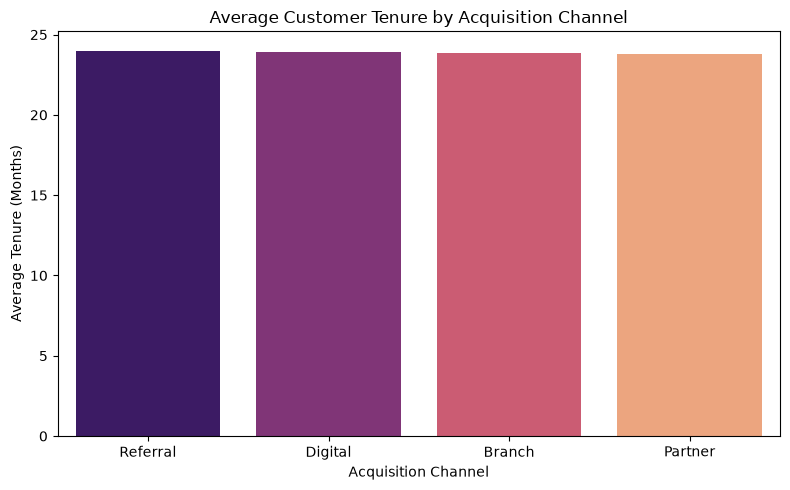

In [24]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=channel_tenure.index,
    y=channel_tenure.values,palette='magma'
)

plt.title("Average Customer Tenure by Acquisition Channel")
plt.xlabel("Acquisition Channel")
plt.ylabel("Average Tenure (Months)")

plt.tight_layout()
plt.show()

Insights: Referral has the highest average customer tenure although the difference between  other channels is small.

*Which states generate the highest transaction value?*

In [25]:
state_value = (
    customer_analysis
    .groupby("state")["total_transaction_value"]
    .sum()
    .sort_values(ascending=False)
)

state_value

state
Maharashtra       8.010921e+08
Gujarat           7.900184e+08
Madhya Pradesh    3.960105e+08
Tamil Nadu        3.956426e+08
Delhi             3.956399e+08
Telangana         3.956116e+08
Karnataka         3.940512e+08
Uttar Pradesh     3.919281e+08
Rajasthan         3.918039e+08
West Bengal       3.902475e+08
Name: total_transaction_value, dtype: float64

C:\Users\USER\AppData\Local\Temp\ipykernel_8844\3873442473.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


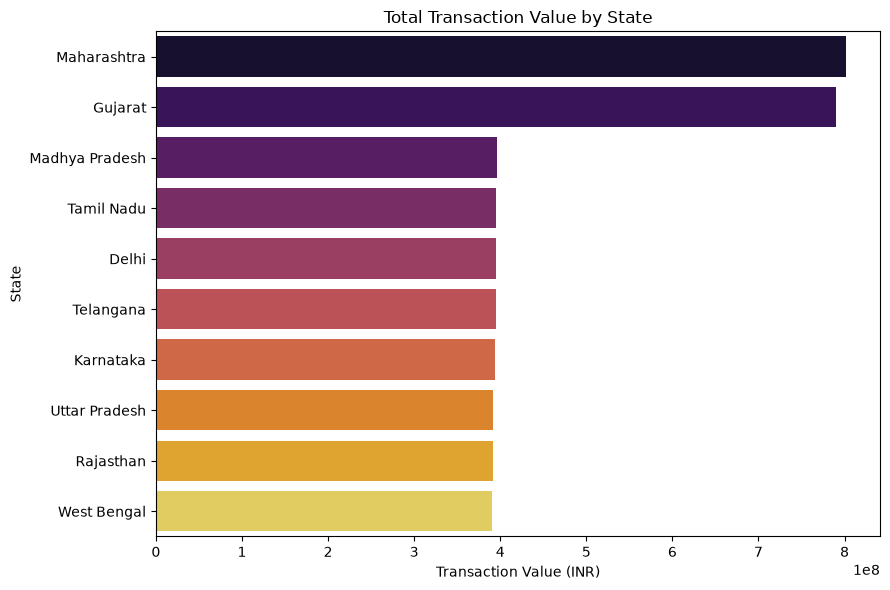

In [27]:
plt.figure(figsize=(9, 6))

sns.barplot(
    x=state_value.values,
    y=state_value.index,palette='inferno'
)

plt.title("Total Transaction Value by State")
plt.xlabel("Transaction Value (INR)")
plt.ylabel("State")

plt.tight_layout()
plt.show()

Insights: Maharashtra generates the highest total transaction value, followed by Gujarat.

*Which chargeback reasons have the lowest recovery rate?*

In [46]:
chargeback_recovery = (
    chargeback_analysis
    .groupby("reason_code")["recovery_rate"]
    .mean()
    .sort_values()
)

chargeback_recovery

reason_code
Processing Error            42.631590
Product Not as Described    42.777985
Fraud                       42.788458
Product Not Received        42.823853
Duplicate                   43.483059
Name: recovery_rate, dtype: float64

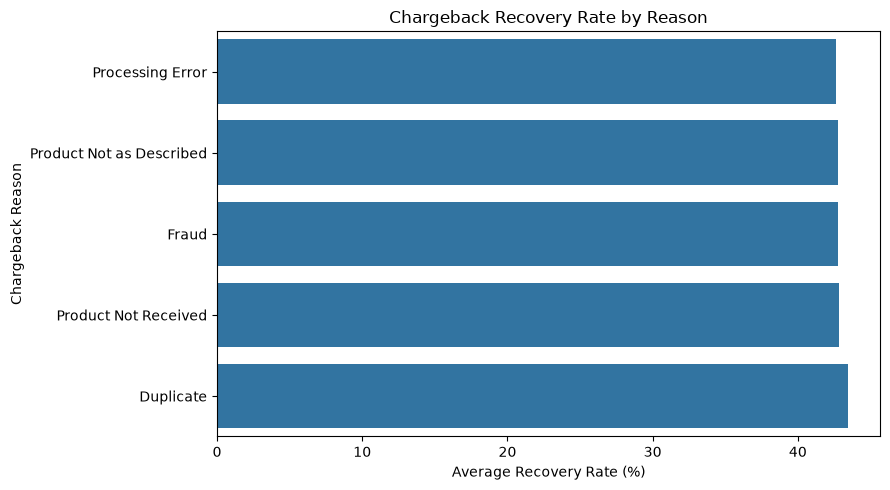

In [48]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=chargeback_recovery.values,
    y=chargeback_recovery.index
)

plt.title("Chargeback Recovery Rate by Reason")
plt.xlabel("Average Recovery Rate (%)")
plt.ylabel("Chargeback Reason")

plt.tight_layout()
plt.show()

Insights :Processing Error  has the lowest recovery rate, highlighting a potential area for stronger prevention or recovery processes.